## Data cube

In [1]:
import numpy as np
import plotly.graph_objects as go

occ_id = 4000836 #923401431 #912350664 #5000321
c1 = 'RdBu_r'
c2 = 'PiYG_r'


data = np.load(f"/marbec-data/RLS-Australia/malpolon/inputs/australia/env/{occ_id}.npy")
data2 = np.load(f"/marbec-data/RLS-Australia/malpolon/inputs/australia/hum/{occ_id}.npy")

In [2]:
def stretch_func(arr, factor, axis):
    length = arr.shape[axis] * factor
    reps = length // arr.shape[axis]
    repeated = np.repeat(arr, reps, axis=axis)
    return repeated.take(range(repeated.shape[axis]-length, repeated.shape[axis]), axis=axis)

def stretch3d(arr, factor=10):
    arr = stretch_func(arr, factor=factor, axis=0)
    arr = stretch_func(arr, factor=factor, axis=1)
    arr = stretch_func(arr, factor=factor, axis=2)
    return arr

def stretch2d(arr, factor=10):
    arr = stretch_func(arr, factor=factor, axis=0)
    arr = stretch_func(arr, factor=factor, axis=1)
    return arr

In [3]:
data = stretch3d(data, factor=20)
data2 = stretch3d(data2, factor=20)

fig = go.Figure()

In [4]:
# Function to create a surface for a given face

def add_face(x, y, z, values, colorscale=c1):

    fig.add_trace(go.Surface(
        x=x, y=y, z=z,
        surfacecolor=values,
        colorscale=colorscale,
        cmin=np.min(data if colorscale==c1 else data2),
        cmax=np.max(data if colorscale==c1 else data2),
    ))

In [ ]:
#################### Cube Env ###########################

N, M, P = data.shape
x = np.arange(N)
y = np.arange(M)
z = np.arange(P)


# Top face (z = P-1)
X, Y = np.meshgrid(x, y)
Z = np.full_like(X, P-1)
add_face(X, Y, Z, data[:, :, -1].T)

# Bottom face (z = 0)
Z = np.full_like(X, 0)
add_face(X, Y, Z, data[:, :, 0].T)

# Left face (x = 0)
Y, Z = np.meshgrid(y, z)
X = np.full_like(Y, 0)
add_face(X, Y, Z, data[0, :, :].T)

# Right face (x = N-1)
X = np.full_like(Y, N-1)
add_face(X, Y, Z, data[-1, :, :].T)

# Back face (y = M-1)
X, Z = np.meshgrid(x, z)
Y = np.full_like(X, M-1)
add_face(X, Y, Z, data[:, -1, :].T)

# Front face (y = 0)
Y = np.full_like(X, 0)
add_face(X, Y, Z, data[:, 0, :].T)

#################### Cube Hum ###########################

N, M, P = data2.shape
x = np.arange(N)
y = np.arange(M)
z = np.arange(P)


# Top face (z = P-1)
X, Y = np.meshgrid(x, y)
Z = np.full_like(X, P-1)
add_face(X, Y, Z + 400, data2[:, :, -1].T, colorscale=c2)

# Bottom face (z = 0)
Z = np.full_like(X, 0)
add_face(X, Y, Z + 400, data2[:, :, 0].T, colorscale=c2)

# Left face (x = 0)
Y, Z = np.meshgrid(y, z)
X = np.full_like(Y, 0)
add_face(X, Y, Z + 400, data2[0, :, :].T, colorscale=c2)

# Right face (x = N-1)
X = np.full_like(Y, N-1)
add_face(X, Y, Z + 400, data2[-1, :, :].T, colorscale=c2)

# Back face (y = M-1)
X, Z = np.meshgrid(x, z)
Y = np.full_like(X, M-1)
add_face(X, Y, Z + 400, data2[:, -1, :].T, colorscale=c2)

# Front face (y = 0)
Y = np.full_like(X, 0)
add_face(X, Y, Z + 400 , data2[:, 0, :].T, colorscale=c2)


#################### Layout ###########################


fig.update_layout(width=800, height=800,
    scene=dict(
        xaxis_title='Latitude',
        yaxis_title='Longitude',
        zaxis_title='Human activity           Environment',
        xaxis=dict(showticklabels=False, showline=False, zeroline=False, showgrid=False, titlefont=dict(size=20)),
        yaxis=dict(showticklabels=False, showline=False, zeroline=False, showgrid=False, titlefont=dict(size=20)),
        zaxis=dict(showticklabels=False, showline=False, zeroline=False, showgrid=False, titlefont=dict(size=20)),
    ),
)

fig.update_traces(showscale=False)

fig.add_scatter3d(x=[N/2,N/2], y=[M/2,M/2], z= [0,680], mode='lines', line_width=10, line_color='black')

fig.show()

## Distances between datasets

In [1]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist

In [2]:
tddata = pd.read_csv('/marbec-data/RLS-Australia/malpolon/xgb/td_compound_values_mm.csv', index_col='survey_id')
rlsdata = pd.read_csv('/marbec-data/RLS-Australia/malpolon/xgb/X_compound_values_mm.csv', index_col='survey_id')
preddata = pd.read_csv('/marbec-data/RLS-Australia/malpolon/xgb/preds_compound_values_mm.csv', index_col='survey_id')
fulldf = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common.csv', index_col='survey_id')
tv_rls = rlsdata[fulldf['subset'] != 'test']
test_rls = rlsdata[fulldf['subset'] == 'test']

preddata['category'] = 'predictions'
tddata['category'] = 'transductive'
tv_rls['category'] = 'trainval'
test_rls['category'] = 'test'

envdata = pd.concat([preddata, tddata, tv_rls, test_rls], axis=0)

/tmp/ipykernel_133747/506066236.py:4: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  fulldf = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common.csv', index_col='survey_id')
/tmp/ipykernel_133747/506066236.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tv_rls['category'] = 'trainval'
/tmp/ipykernel_133747/506066236.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_rls['category'] = 'test'


In [12]:
def min_dist_to_each_class(X, y):

    """
    X: N * 60 - feature matrix
    y: N - class labels
    
    """
    classes = np.unique(y)
    class_indices = {c: np.where(y == c)[0] for c in classes}

    result = np.zeros((len(X), len(classes)))

    for i, c1 in enumerate(classes):
        idx1 = class_indices[c1]
        X1 = X[idx1]

        for j, c2 in enumerate(classes):
            if c1 == c2:
                result[idx1, j] = 0.0
                continue

            idx2 = class_indices[c2]
            X2 = X[idx2]

            D = cdist(X1, X2)
            result[idx1, j] = D.min(axis=1)

    return classes, result

In [13]:
X, y = envdata.drop(columns='category').fillna(0).values, envdata['category'].values
classes, dmin = min_dist_to_each_class(X, y)

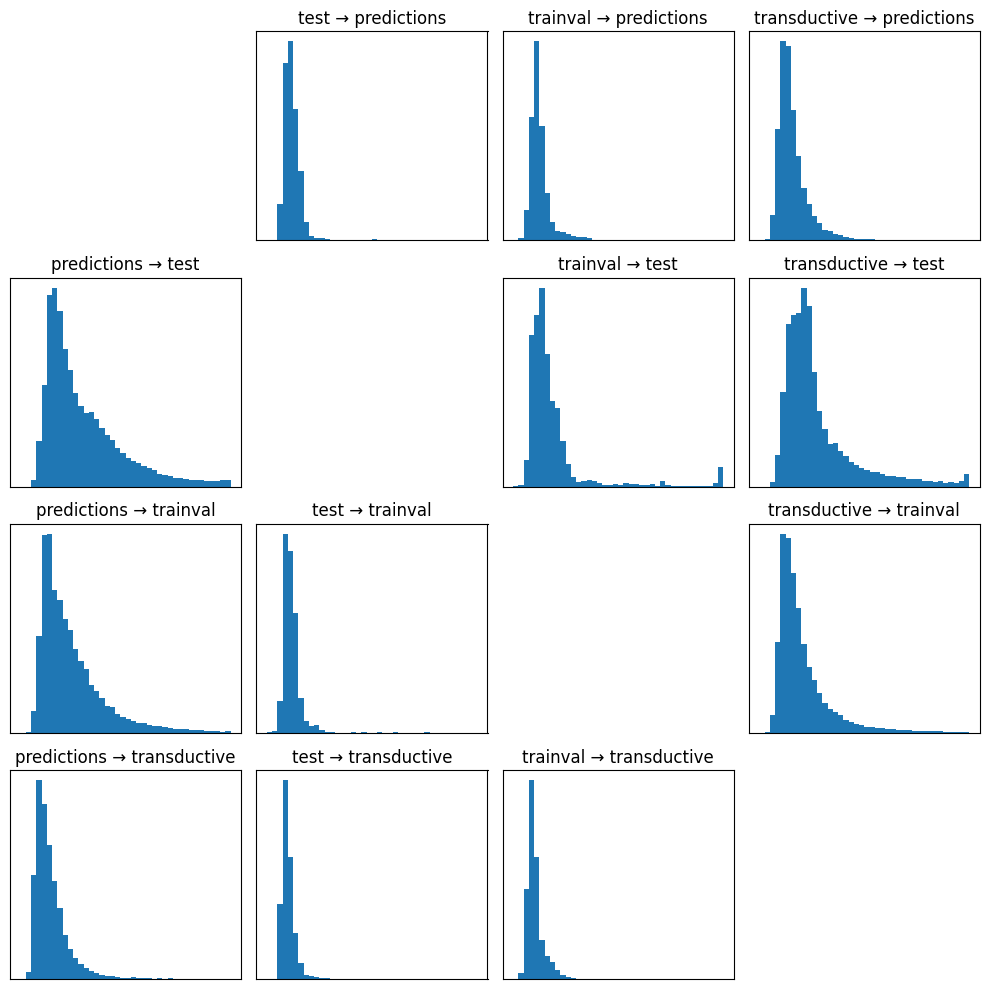

In [19]:
import numpy as np
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

idx = {c: np.where(y == c)[0] for c in classes}

dists = []

fig, axes = plt.subplots(len(classes), len(classes), figsize=(10, 10))


xmin, xmax = np.percentile(dmin.flatten(), [1, 99])
bins = np.linspace(xmin, xmax, 41)

# second pass: plot
for i, c1 in enumerate(classes):
    for j, c2 in enumerate(classes):
        ax = axes[j, i]

        if c1 == c2:
            ax.axis("off")
            continue

        ax.hist(dmin[idx[c1],j], bins=bins, density=True)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{c1} → {c2}")

plt.tight_layout()
plt.show()

## Distinctiveness

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import pairwise_distances
from pathlib import Path
from sklearn.decomposition import PCA

rlsdata = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/biomass_lognorm.csv', index_col='survey_id')
testdata = rlsdata[rlsdata['subset'] == 'test'].iloc[:,28:-1]

tvdata = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/biomass_lognorm_trainval.csv', index_col='survey_id').iloc[:,28:-1]

/tmp/ipykernel_185785/2850378127.py:7: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  rlsdata = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/biomass_lognorm.csv', index_col='survey_id')
/tmp/ipykernel_185785/2850378127.py:10: DtypeWarning: Columns (22,25) have mixed types. Specify dtype option on import or set low_memory=False.
  tvdata = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/biomass_lognorm_trainval.csv', index_col='survey_id').iloc[:,28:-1]


#### Seascapes

In [2]:
output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')

test_emb = np.load(output_path / '37_mm4_transductif-2025-12-02_12-47' / 'embedding.npy')
tv_emb = np.load(output_path / '37_mm4_transductif-2025-12-02_12-47'/ 'embedding_trainval.npy')

test_df = pd.DataFrame(test_emb, columns=range(test_emb.shape[1]), index = testdata.index)
tv_df = pd.DataFrame(tv_emb, columns=range(tv_emb.shape[1]), index = tvdata.index)

emb_df = pd.concat([test_df, tv_df], axis=0)

In [5]:
pca = PCA(n_components=10)
pca.fit(emb_df.values)
pca_emb = pca.transform(emb_df.values)

pca_df = pd.DataFrame(pca_emb, columns=range(10), index = emb_df.index).astype(np.float16)

dist = pairwise_distances(pca_df.values, metric="euclidean", n_jobs=15)
dist_df = pd.DataFrame(dist, index=pca_df.index, columns=pca_df.index).astype(np.float16)
dist_df.to_csv('/data/data/RLS/embedding_euclidean.csv')

#### Assemblages

In [6]:
dist = pairwise_distances(rlsdata.iloc[:,28:-1].values, metric="braycurtis", n_jobs=15)
dist_df = pd.DataFrame(dist, index=rlsdata.index, columns=rlsdata.index).astype(np.float16)
dist_df.to_csv('/data/data/RLS/assemblages_braycurtis.csv')

# dist = pairwise_distances((rlsdata.iloc[:,28:-1] > 0).astype(int).values, (rlsdata.iloc[:,28:-1] > 0).astype(int).values, metric="jaccard")
# dist_df = pd.DataFrame(dist, index=rlsdata.index, columns=rlsdata.index).astype(np.float16)
# dist_df.to_csv('/data/data/RLS/assemblages_jaccard.csv')

#### Plot

In [3]:
assemblages_dist = pd.read_csv('/data/data/RLS/assemblages_braycurtis.csv', index_col=0).values.ravel()
embeddings_dist = pd.read_csv('/data/data/RLS/embedding_euclidean.csv', index_col=0).values.ravel()
summary = np.stack([assemblages_dist, embeddings_dist], axis=0)


In [4]:
summary16 = summary.astype(np.float16)

(array([7.11900000e+04, 1.16564000e+05, 7.79776000e+05, 4.14702600e+06,
        1.48212560e+07, 3.41122440e+07, 5.51094220e+07, 7.28023080e+07,
        9.51923300e+07, 4.75636732e+08]),
 array([0.        , 0.09997559, 0.19995117, 0.29980469, 0.39990234,
        0.5       , 0.59960938, 0.69970703, 0.79980469, 0.89990234,
        1.        ]),
 <BarContainer object of 10 artists>)

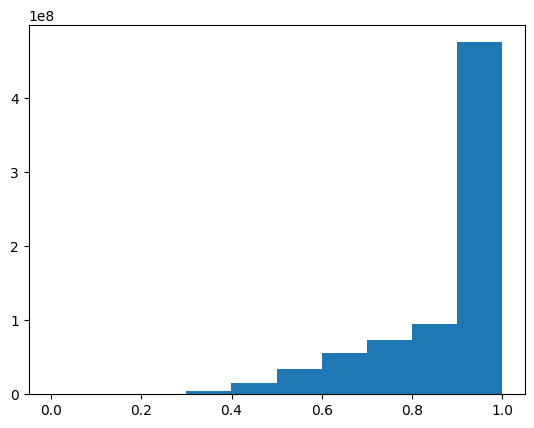

In [10]:
plt.hist(summary16[0,:])

(0.5, 1.0)

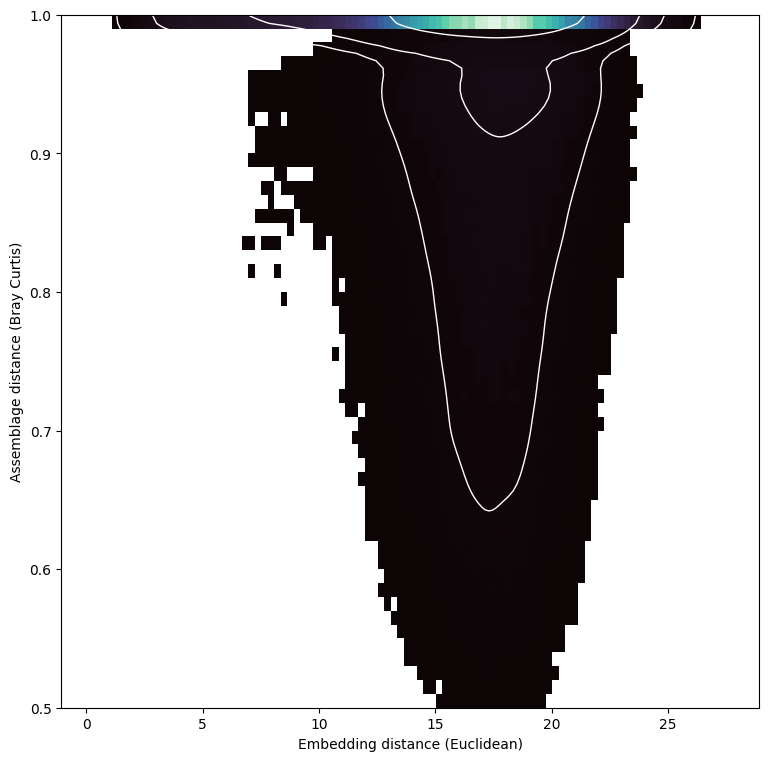

In [11]:
from matplotlib import pyplot as plt
import seaborn as sns
x = summary16[1,::200]
y = summary16[0,::200]

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
#sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=100, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
ax.set(xlabel='Embedding distance (Euclidean)', ylabel='Assemblage distance (Bray Curtis)')
ax.set_ylim(0.5, 1)